**Load the Dataset** — Reads the Heart Disease CSV file into a pandas DataFrame and displays the first few rows to confirm it loaded correctly. This is a HeartDisease Dataset where in target feature, `0` indicate `No-Disease` and `1` indicate `Disease`.

In [525]:
import pandas as pd
df = pd.read_csv("/content/HeartDisease.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


**Statistical Summary** — Generates descriptive statistics (mean, std, min, max, quartiles) for all numerical columns to get a quick overview of the data distribution.

In [526]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


**Column Names** — Prints the list of feature names (columns) present in the dataset.

In [527]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


**Target Class Distribution** — Counts how many samples belong to each class (0 = no disease, 1 = disease) to check for class imbalance.

In [528]:
df['target'].value_counts()

,count
target,
1,526
0,499


**Dataset Shape** — Displays the total number of rows (samples) and columns (features) in the dataset.

In [529]:
df.shape

(1025, 14)

**Check for Missing Values** — Identifies whether any column contains NaN/null values that would need to be handled before training.

In [530]:
df.isna().any()

,0
age,False
sex,False
cp,False
trestbps,False
chol,False
fbs,False
restecg,False
thalach,False
exang,False
oldpeak,False


**Drop Empty Rows** — Removes any rows where all values are missing, ensuring the dataset is clean.

In [531]:
df = df.dropna(how='all')

**Separate Features and Labels** — Splits the DataFrame into input features `X` (all columns except target) and the output label `y` (the target column).

In [532]:
X = df.drop(columns=['target']).values
y = df['target'].values

**Verify Shapes** — Prints the dimensions of `X` and `y` to confirm the split was performed correctly.

In [533]:
print(X.shape,y.shape,sep="\n")

(1025, 13)
(1025,)


**Train/Test Split** — Divides the data into 80% training and 20% testing sets using a fixed random seed for reproducibility.

In [534]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

**Sigmoid Activation Function** — Defines the sigmoid function `f(z) = 1 / (1 + e^-z)`, which fits any real number into the range (0, 1).

In [535]:
def f(z):
  z = np.clip(z, -500, 500)
  return 1/(1+np.exp(-z))

**Initialize Hyperparameters and Weights** — Sets the number of training epochs, learning rate (`eta`), and randomly initializes the weight vector `w` and bias `b`.

In [536]:
import numpy as np
epochs=500
eta = 0.01

w = np.random.randn(X_train.shape[1])
b=np.random.randn()

**Training Loop (Gradient Descent)** — Trains the logistic regression model from scratch using gradient descent. For each sample, it computes the prediction, calculates the squared error loss, and updates weights and bias to minimize it.

In [537]:
loss_history = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for i in range(len(X_train)):
        x = X_train[i]
        y_i = y_train[i]

        z = np.dot(x, w) + b
        a = f(z)

        error = a - y_i
        loss = error ** 2
        epoch_loss += loss

        # Gradient descent weight update
        w -= eta * 2 * error * x
        b -= eta * 2 * error

    epoch_loss /= len(X_train)          # Average loss this epoch
    loss_history.append(epoch_loss)

    if epoch == 0:
        print(f"Epoch {epoch+1:>3}/{epochs} | Loss = {epoch_loss:.6f} | Loss% = {epoch_loss*100:.4f}%")
    else:
        prev_loss = loss_history[-2]
        reduction = ((prev_loss - epoch_loss) / prev_loss) * 100 if prev_loss != 0 else 0
        direction = '↓' if reduction >= 0 else '↑'  # ↑ means loss went UP
        print(f"Epoch {epoch+1:>3}/{epochs} | Loss = {epoch_loss:.6f} "
              f"| Loss% = {epoch_loss*100:.4f}% "
              f"| Reduction = {direction}{abs(reduction):.2f}%")


Epoch   1/500 | Loss = 0.462476 | Loss% = 46.2476%
Epoch   2/500 | Loss = 0.414455 | Loss% = 41.4455% | Reduction = ↓10.38%
Epoch   3/500 | Loss = 0.407079 | Loss% = 40.7079% | Reduction = ↓1.78%
Epoch   4/500 | Loss = 0.407311 | Loss% = 40.7311% | Reduction = ↑0.06%
Epoch   5/500 | Loss = 0.414806 | Loss% = 41.4806% | Reduction = ↑1.84%
Epoch   6/500 | Loss = 0.398524 | Loss% = 39.8524% | Reduction = ↓3.93%
Epoch   7/500 | Loss = 0.408751 | Loss% = 40.8751% | Reduction = ↑2.57%
Epoch   8/500 | Loss = 0.421970 | Loss% = 42.1970% | Reduction = ↑3.23%
Epoch   9/500 | Loss = 0.401100 | Loss% = 40.1100% | Reduction = ↓4.95%
Epoch  10/500 | Loss = 0.418291 | Loss% = 41.8291% | Reduction = ↑4.29%
Epoch  11/500 | Loss = 0.413349 | Loss% = 41.3349% | Reduction = ↓1.18%
Epoch  12/500 | Loss = 0.391469 | Loss% = 39.1469% | Reduction = ↓5.29%
Epoch  13/500 | Loss = 0.393767 | Loss% = 39.3767% | Reduction = ↑0.59%
Epoch  14/500 | Loss = 0.398862 | Loss% = 39.8862% | Reduction = ↑1.29%
Epoch  15/50

**Generate Predictions on Test Set** — Runs the trained model on every test sample. if the sigmoid output ≥ 0.5, predicts class 1 (disease), otherwise class 0 (no-disease).

In [538]:
pred = []

for x in X_test:
  z = np.dot(x,w)+b
  a = f(z)

  pred.append(1 if a>=0.5 else 0)
pred = np.array(pred)

**Loss Curve Plot** — Visualises how the training loss decreased over all epochs. A smooth downward curve confirms the model learned correctly.

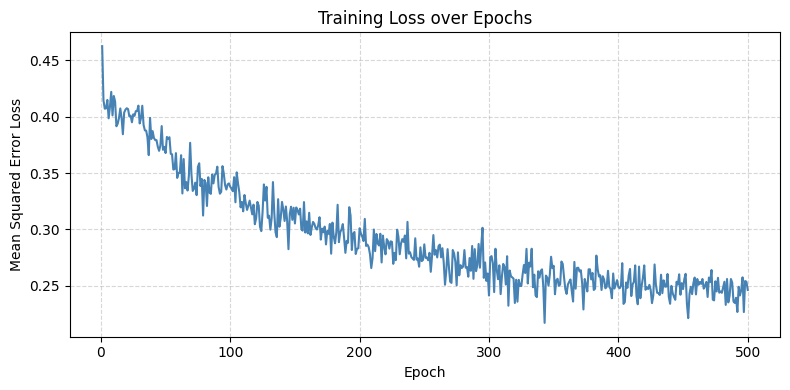

In [539]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), loss_history, color='steelblue', linewidth=1.5)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**Epoch-wise Loss % Table (first 10 & last 10 epochs)** — Shows the exact loss percentage and reduction at the start and end of training.

In [540]:
import pandas as pd

reductions = [None] + [
    ((loss_history[i-1] - loss_history[i]) / loss_history[i-1]) * 100
    for i in range(1, len(loss_history))
]

table = pd.DataFrame({
    'Epoch':     range(1, epochs+1),
    'Loss':      [f'{l:.6f}' for l in loss_history],
    'Loss %':    [f'{l*100:.4f}%' for l in loss_history],
    'Reduction': ['—'] + [f'{r:+.2f}%' for r in reductions[1:]]
})

display(pd.concat([table.head(10), table.tail(10)]).reset_index(drop=True))


,Epoch,Loss,Loss %,Reduction
0,1,0.462476,46.2476%,—
1,2,0.414455,41.4455%,+10.38%
2,3,0.407079,40.7079%,+1.78%
3,4,0.407311,40.7311%,-0.06%
4,5,0.414806,41.4806%,-1.84%
5,6,0.398524,39.8524%,+3.93%
6,7,0.408751,40.8751%,-2.57%
7,8,0.421970,42.1970%,-3.23%
8,9,0.401100,40.1100%,+4.95%
9,10,0.418291,41.8291%,-4.29%


**Key Metrics Summary** — Displaying all important evaluation values in one place.

In [541]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, pred)
recall    = recall_score(y_test, pred)
f1        = f1_score(y_test, pred)
accuracy  = np.mean(pred == y_test)

print('='*40)
print(f'  Accuracy  : {accuracy*100:.2f}%')
print(f'  Precision : {precision*100:.2f}%')
print(f'  Recall    : {recall*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print('='*40)
print(f'  Initial Loss (Epoch 1) : {loss_history[0]*100:.4f}%')
print(f'  Final   Loss (Epoch {epochs}): {loss_history[-1]*100:.4f}%')
print(f'  Total Loss Reduction   : {((loss_history[0]-loss_history[-1])/loss_history[0])*100:.2f}%')
print('='*40)


  Accuracy  : 71.22%
  Precision : 86.67%
  Recall    : 50.49%
  F1-Score  : 63.80%
  Initial Loss (Epoch 1) : 46.2476%
  Final   Loss (Epoch 500): 24.6341%
  Total Loss Reduction   : 46.73%


**Final Learned Parameters** — Final trained weight vector `w` and bias `b`. Showing these proves the algorithm genuinely learned from data.

In [542]:
print('Bias (b):', round(b, 6))
print('Weights (w):')
feature_names = df.drop(columns=['target']).columns.tolist()
for name, weight in zip(feature_names, w):
    print(f'  {name:>20s} : {weight:+.6f}')


Bias (b): -8.899589
Weights (w):
                   age : +3.909680
                   sex : -338.020339
                    cp : +440.204547
              trestbps : -7.679985
                  chol : -8.119470
                   fbs : -66.817722
               restecg : +111.294098
               thalach : +19.940048
                 exang : -183.810106
               oldpeak : -363.579711
                 slope : +183.071532
                    ca : -449.750336
                  thal : -366.944309
